Extracting diamonds.csv from /content/diamonds.csv.zip...
Extraction complete.
First 5 Rows
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  

Shape
(53940, 11)

Data Types
Unnamed: 0      int64
carat         float64
cut            object
color          object
clarity        object
depth         float64
table         float64
price           int64
x             float64
y             float64
z             float64
dtype: object

Statistics
         Unnamed: 0         carat         depth         table       

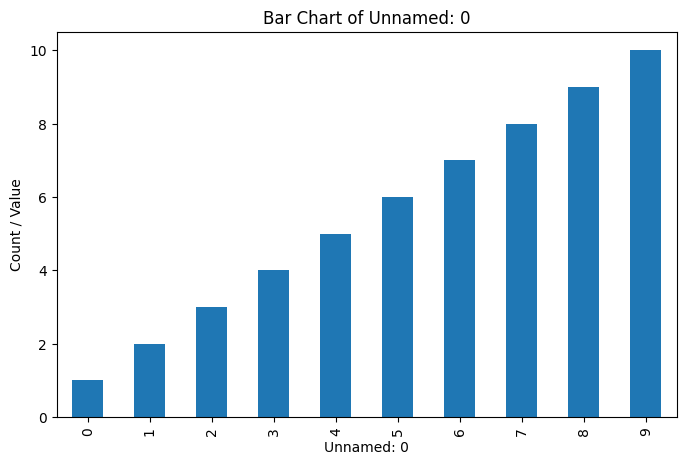

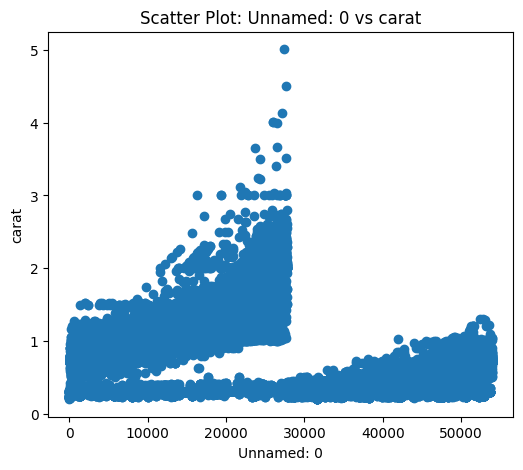

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

# Define the paths
zip_file_path = '/content/diamonds.csv.zip'
csv_file_name = 'diamonds.csv'

# Check if the CSV file exists, if not, extract it from the zip
if not os.path.exists(csv_file_name):
    print(f"Extracting {csv_file_name} from {zip_file_path}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Extraction complete.")
else:
    print(f"{csv_file_name} already exists. Skipping extraction.")

# Read dataset
df = pd.read_csv(
    csv_file_name,
    engine="python",
    on_bad_lines="skip"
)

print("First 5 Rows")
print(df.head())

print("\nShape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

print("\nStatistics")
print(df.describe())

# Numerical columns
num_cols = df.select_dtypes(include="number").columns

# Filtering
if len(num_cols) > 0:
    filtered = df[df[num_cols[0]] > df[num_cols[0]].mean()]
    print("\nFiltered Data")
    print(filtered.head())

# Sorting
if len(num_cols) > 0:
    sorted_df = df.sort_values(by=num_cols[0], ascending=False)
    print("\nSorted Data")
    print(sorted_df.head())

# Statistical Analysis
for col in num_cols:
    print("\nColumn:", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Standard Deviation:", df[col].std())

# Grouping
cat_cols = df.select_dtypes(include=object).columns # Use object for string-like categories

if len(cat_cols) > 0 and len(num_cols) > 0:
    # Using the first categorical column for grouping, ensure it exists
    grouped_col = cat_cols[0] # Assuming 'cut' or 'color' will be the first
    grouped = df.groupby(grouped_col)[num_cols].mean()
    print(f"\nGrouped Data by {grouped_col}")
    print(grouped)
elif len(cat_cols) == 0:
    print("\nNo categorical columns found for grouping.")
else:
    print("\nNo numerical columns found for grouping aggregation.")

# Correlation
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    print("\nCorrelation Matrix")
    print(corr)
else:
    print("\nNot enough numerical columns to compute correlation matrix.")

# Bar Chart
if len(num_cols) > 0:
    plt.figure(figsize=(8,5))
    df[num_cols[0]].head(10).plot(kind="bar")
    plt.title(f"Bar Chart of {num_cols[0]}")
    plt.xlabel(num_cols[0])
    plt.ylabel("Count / Value")
    plt.show()
else:
    print("\nNo numerical columns for bar chart.")

# Scatter Plot
if len(num_cols) >= 2:
    plt.figure(figsize=(6,5))
    plt.scatter(df[num_cols[0]], df[num_cols[1]])
    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])
    plt.title(f"Scatter Plot: {num_cols[0]} vs {num_cols[1]}")
    plt.show()
else:
    print("\nNot enough numerical columns for scatter plot.")